Aircraft Electrical Power Management & Fault Detection System

## Project Overview

This project is a simplified simulation of an aircraft electrical power
system. I developed it to explore how electrical power can be distributed
between essential and non-essential aircraft systems and how the system
could respond to faults.

The project combines concepts from electrical engineering and software
engineering. Python is used to model the electrical system, calculate
power and current requirements, detect faults and simulate emergency
conditions.

The system is not intended to represent a real certified aircraft system.
Instead, it is an educational model that allows different failure
conditions to be investigated safely.

## Project Questions

1. Can the electrical system supply all connected loads?
2. What happens when the main generator fails?
3. How can essential systems be protected during a power failure?
4. How can an electrical overload be detected?
5. How does battery capacity affect emergency operation?

In [20]:
# System configuration

VOLTAGE = 28

GENERATOR_CURRENT = 40
GENERATOR_POWER = VOLTAGE * GENERATOR_CURRENT

BATTERY_CAPACITY_AH = 20
BATTERY_ENERGY_WH = VOLTAGE * BATTERY_CAPACITY_AH

loads = {
    "Flight Computer": {
        "power": 150,
        "bus": "Essential",
        "priority": 1,
        "breaker": 7
    },

    "Navigation System": {
        "power": 100,
        "bus": "Essential",
        "priority": 2,
        "breaker": 5
    },

    "Communication System": {
        "power": 75,
        "bus": "Essential",
        "priority": 3,
        "breaker": 4
    },

    "Cabin Lighting": {
        "power": 100,
        "bus": "Utility",
        "priority": 4,
        "breaker": 5
    },

    "Cabin Systems": {
        "power": 200,
        "bus": "Utility",
        "priority": 5,
        "breaker": 10
    },

    "Auxiliary Pump": {
        "power": 250,
        "bus": "Utility",
        "priority": 6,
        "breaker": 12
    }
}

print("Aircraft electrical system configured.")
print(f"System voltage: {VOLTAGE} V")
print(f"Generator capacity: {GENERATOR_POWER} W")
print(f"Battery energy: {BATTERY_ENERGY_WH} Wh")

Aircraft electrical system configured.
System voltage: 28 V
Generator capacity: 1120 W
Battery energy: 560 Wh


## Electrical Load Analysis

The current required by each electrical load is calculated using:

\[
I = \frac{P}{V}
\]

where P is power in watts and V is system voltage.

In [21]:
def calculate_loads(loads):
    total_power = 0

    print("Electrical Load Analysis")
    print("-" * 45)

    for name, data in loads.items():
        power = data["power"]
        current = power / VOLTAGE

        total_power += power

        print(f"{name}: {power} W | {current:.2f} A")

    total_current = total_power / VOLTAGE

    print("-" * 45)
    print(f"Total power: {total_power} W")
    print(f"Total current: {total_current:.2f} A")

    return total_power, total_current


total_power, total_current = calculate_loads(loads)

Electrical Load Analysis
---------------------------------------------
Flight Computer: 150 W | 5.36 A
Navigation System: 100 W | 3.57 A
Communication System: 75 W | 2.68 A
Cabin Lighting: 100 W | 3.57 A
Cabin Systems: 200 W | 7.14 A
Auxiliary Pump: 250 W | 8.93 A
---------------------------------------------
Total power: 875 W
Total current: 31.25 A


## Fault Detection

The system compares the electrical demand with the available generator
capacity. Individual loads are also checked against their circuit-breaker
ratings.

In [22]:
def check_system_status(loads):
    total_power = sum(data["power"] for data in loads.values())
    generator_utilisation = total_power / GENERATOR_POWER

    print("System Status")
    print("-" * 45)

    if total_power > GENERATOR_POWER:
        print("FAULT: Generator overload detected")
    else:
        print("Generator operating within capacity")

    print(f"Generator utilisation: {generator_utilisation * 100:.1f}%")

    print("\nCircuit protection:")

    for name, data in loads.items():
        current = data["power"] / VOLTAGE
        breaker = data["breaker"]

        if current > breaker:
            print(f"{name}: BREAKER TRIPPED")
        else:
            print(f"{name}: Normal")


check_system_status(loads)

System Status
---------------------------------------------
Generator operating within capacity
Generator utilisation: 78.1%

Circuit protection:
Flight Computer: Normal
Navigation System: Normal
Communication System: Normal
Cabin Lighting: Normal
Cabin Systems: Normal
Auxiliary Pump: Normal


In [23]:
def load_shedding(available_power, loads):

    active_loads = {}
    remaining_power = available_power

    # Keep the highest-priority systems first
    sorted_loads = sorted(
        loads.items(),
        key=lambda item: item[1]["priority"]
    )

    for name, data in sorted_loads:

        if data["power"] <= remaining_power:
            active_loads[name] = data
            remaining_power -= data["power"]

    return active_loads

In [24]:
emergency_power = 400

active_loads = load_shedding(emergency_power, loads)

print("Emergency Power Management")
print("-" * 45)

for name in active_loads:
    print(f"POWERED: {name}")

print("\nLoads disconnected:")

for name in loads:
    if name not in active_loads:
        print(f"SHED: {name}")

Emergency Power Management
---------------------------------------------
POWERED: Flight Computer
POWERED: Navigation System
POWERED: Communication System

Loads disconnected:
SHED: Cabin Lighting
SHED: Cabin Systems
SHED: Auxiliary Pump


 Experiments

Experiment 1 — Generator Failure

The generator is assumed to fail completely. The system must determine
which loads can continue operating using emergency battery power.

Experiment 2 — Increasing Electrical Demand

The total electrical demand is gradually increased to determine when
generator capacity is exceeded.

Experiment 3 — Battery Capacity

Battery capacity is varied to investigate its effect on emergency
operating time.

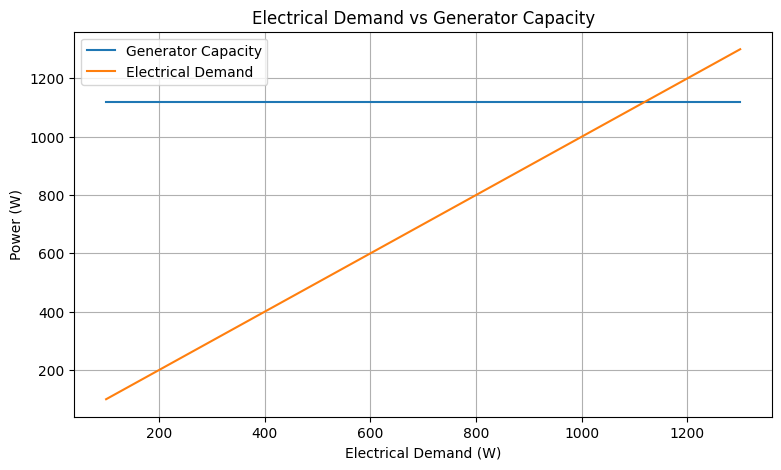

In [25]:
import matplotlib.pyplot as plt

loads_tested = range(100, 1301, 50)

generator_capacity = GENERATOR_POWER

plt.figure(figsize=(9, 5))

plt.plot(
    loads_tested,
    [generator_capacity] * len(loads_tested),
    label="Generator Capacity"
)

plt.plot(
    loads_tested,
    loads_tested,
    label="Electrical Demand"
)

plt.xlabel("Electrical Demand (W)")
plt.ylabel("Power (W)")
plt.title("Electrical Demand vs Generator Capacity")
plt.legend()
plt.grid(True)

plt.show()

In [26]:
import gradio as gr

GENERATOR_CAPACITY = 1120

def run_scenario(scenario):
    if scenario == "Normal Operation":
        demand = 875
        status = "System operating normally."

    elif scenario == "Generator Failure":
        demand = 325
        status = "Generator failure detected. Essential loads are prioritised using battery backup."

    elif scenario == "Electrical Overload":
        demand = 1125
        status = "Generator overload detected. Demand exceeds generator capacity."

    else:
        demand = 0
        status = "Select a scenario."

    if demand > GENERATOR_CAPACITY:
        power_status = "OVERLOAD"
    else:
        power_status = "Within generator capacity"

    return demand, GENERATOR_CAPACITY, power_status, status


interface = gr.Interface(
    fn=run_scenario,
    inputs=gr.Dropdown(
        ["Normal Operation", "Generator Failure", "Electrical Overload"],
        label="Select Scenario"
    ),
    outputs=[
        gr.Number(label="Electrical Demand (W)"),
        gr.Number(label="Generator Capacity (W)"),
        gr.Textbox(label="Power Status"),
        gr.Textbox(label="System Response")
    ],
    title="Aircraft Electrical Power Management System",
    description="Simulate different aircraft electrical operating conditions."
)

interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://fc1fb897e8776c3b21.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


**RESULTSt**

The simulations were used to investigate the behaviour of the aircraft electrical system under different conditions.

| Scenario            | Electrical Demand | Generator Capacity | Result                      |
| ------------------- | ----------------: | -----------------: | --------------------------- |
| Normal operation    |             875 W |             1120 W | Normal operation            |
| Generator overload  |            1125 W |             1120 W | Generator overload detected |
| Navigation overload |     Simulated 7 A |  Breaker limit 5 A | Breaker trips               |

### Observations

Under normal operating conditions, the total electrical demand is 875  which is below the generator capacity of 1120 W.

When the auxiliary pump demand was increased, the total demand reached 1125 W. This exceeded the generator capacity allowing the simulation to identify an overload condition.



CONCLUSION

This project created a model of an aircraft electrical power system using Python.

The simulation was able to calculate power and current needs figure out generator loading keep track of individual circuit breaker limits and act out generator failure.

The load-shedding model showed how electrical loads can be ranked when there is not power available. This showed how software can be used to help manage a system during unusual situations.

The project is kept simple. Does not show a certified aircraft electrical system. Actual aircraft systems have more complicated power distribution, backup systems, protection measures and certification rules.

The main problem, with this model is that it assumes voltage and power use. Later versions could include changing loads, several generators, battery efficiency and complicated electrical bus setups.